In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [10]:
# pivot table

df=sns.load_dataset('tips')

df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='mean')
# df.groupby(['sex','smoker'])['total_bill'].mean().unstack()

smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [ ]:
# multidimentional
df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'min','tip':'max','total_bill':'sum'})

size                                     tip               \
day            Thur          Fri           Sat    Sun  Thur          Fri   
time          Lunch Dinner Lunch Dinner Dinner Dinner Lunch Dinner Lunch   
sex    smoker                                                              
Male   Yes      2.0    NaN   1.0    2.0    2.0    2.0  5.00    NaN  2.20   
       No       2.0    NaN   NaN    2.0    2.0    2.0  6.70    NaN   NaN   
Female Yes      2.0    NaN   2.0    2.0    1.0    2.0  5.00    NaN  3.48   
       No       1.0    2.0   3.0    2.0    1.0    2.0  5.17    3.0  3.00   

                                   total_bill                                \
day                     Sat    Sun       Thur           Fri             Sat   
time          Dinner Dinner Dinner      Lunch Dinner  Lunch  Dinner  Dinner   
sex    smoker                                                                 
Male   Yes      4.73  10.00    6.5     191.71    NaN  34.16  129.46  589.62   
       No       3.50   9.00    6.0     369.73    NaN    NaN   34.95  637.73   
Female Yes      4.30   6.50    4.0     134.53    NaN  39.78   48.80  304.00   
       No       3.25   4.67    5.2     381.58  18.78  15.98   22.75  247.05   

                       
day               Sun  
time           Dinner  
sex    smoker          
Male   Yes     392.12  
       No      877.34  
Female Yes      66.16  
       No      291.54

In [16]:
# margins
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True)

smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [30]:
expenses.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


<Axes: xlabel='month'>

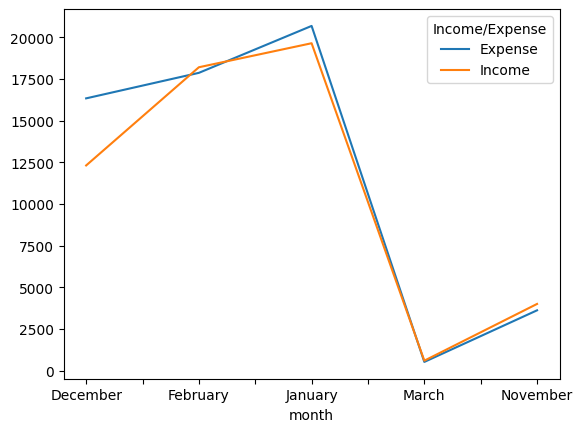

In [35]:
# plotting graphs
expenses=pd.read_csv('expense_data.csv')
expenses['Date']=pd.to_datetime(expenses['Date'])
expenses['month']=expenses['Date'].dt.month_name()
expenses.pivot_table(index='month',columns='Income/Expense',values='INR',fill_value=0,aggfunc='sum').plot()

In [66]:
# vectorized string operations
titanic=pd.read_csv('titanic.csv')
# Common Functions: lower/upper/capatilize/title
titanic['Name'].str.lower()
titanic['Name'].str.upper()
titanic['Name'].str.capitalize()
titanic['Name'].str.title()

# len
titanic[titanic['Name'].str.len()==titanic['Name'].str.len().max()]['Name'].values[0]

#strip
titanic['Name'].str.strip()

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [69]:
# split->get
# Adding 3 new column: lastname, firstname, title

titanic[['title','firstname']]=titanic['Name'].str.split(',').str.get(1).str.strip().str.split(' ',n=1,expand=True)
titanic['lastname']=titanic['Name'].str.split(',').str.get(0)
titanic['title'].value_counts()

title
Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Major.         2
Mlle.          2
Col.           2
Don.           1
Mme.           1
Ms.            1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Name: count, dtype: int64

In [ ]:
# replace

titanic['title']=titanic['title'].str.replace('Ms.','Miss.')
titanic['title']=titanic['title'].str.replace('Mlle.','Miss.')
titanic['title'].value_counts()

title
Mr.          517
Miss.        185
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Major.         2
Col.           2
Don.           1
Mme.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Name: count, dtype: int64

In [76]:
# filtering
# startswith/endswith
titanic[titanic['firstname'].str.startswith('A')]
titanic[titanic['firstname'].str.endswith('A')]

# isdigit/isalpha
titanic[titanic['firstname'].str.isdigit()]
titanic[titanic['firstname'].str.isalpha()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title,firstname,lastname
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.,Laina,Heikkinen
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr.,James,Moran
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,Miss.,Elizabeth,Bonnell
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q,Master.,Eugene,Rice
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C,Mrs.,Fatima,Masselmani
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S,Mr.,Nedelio,Petroff
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S,Mr.,Kristo,Laleff
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S,Mr.,Johann,Markun
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev.,Juozas,Montvila


In [78]:
# applying regex
# contains
# search john -> both case
titanic[titanic['firstname'].str.contains('john',case=False)]

# find lastnames starting and ending with vowels
titanic[titanic['lastname'].str.contains("^[aeiouAEIOU].+[aeiouAEIOU]$")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title,firstname,lastname
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,NaN,C,Don.,Manuel E,Uruchurtu
49,50,0,3,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,18.0,1,0,349237,17.8000,NaN,S,Mrs.,Josef (Josefine Franchi),Arnold-Franchi
207,208,1,3,"Albimona, Mr. Nassef Cassem",male,26.0,0,0,2699,18.7875,NaN,C,Mr.,Nassef Cassem,Albimona
210,211,0,3,"Ali, Mr. Ahmed",male,24.0,0,0,SOTON/O.Q. 3101311,7.0500,NaN,S,Mr.,Ahmed,Ali
353,354,0,3,"Arnold-Franchi, Mr. Josef",male,25.0,1,0,349237,17.8000,NaN,S,Mr.,Josef,Arnold-Franchi
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C,Mr.,Ramon,Artagaveytia
518,519,1,2,"Angle, Mrs. William A (Florence ""Mary"" Agnes H...",female,36.0,1,0,226875,26.0000,NaN,S,Mrs.,"William A (Florence ""Mary"" Agnes Hughes)",Angle
784,785,0,3,"Ali, Mr. William",male,25.0,0,0,SOTON/O.Q. 3101312,7.0500,NaN,S,Mr.,William,Ali
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S,Mr.,Ilmari Rudolf,Alhomaki


In [85]:
# slicing

titanic['Name'].str[:6]

0      Braund
1      Cuming
2      Heikki
3      Futrel
4      Allen,
        ...  
886    Montvi
887    Graham
888    Johnst
889    Behr, 
890    Dooley
Name: Name, Length: 891, dtype: str

In [92]:
# DateTime in pandas
# Timestamp
pd.Timestamp('2026/6/8')

Timestamp('2026-06-08 00:00:00')

In [93]:
# variations
pd.Timestamp('2023-6-8')
pd.Timestamp('2023, 6, 8')

Timestamp('2023-06-08 00:00:00')

In [94]:
# Using text
pd.Timestamp('8th June 2026')

Timestamp('2026-06-08 00:00:00')

In [95]:
# Providing Time Also
pd.Timestamp('6th June 2026 3:42PM')

Timestamp('2026-06-06 15:42:00')

In [125]:
# Using datetime.datetime object
from datetime import datetime as dt
time=pd.Timestamp(dt(2026,6,8,3,45,32))
time

Timestamp('2026-06-08 03:45:32')

In [ ]:
# Fetching attribues
time.year
time.month
time.day
time.hour
time.minute
time.second

'June'

In [123]:
date=np.array('2026-06-08',dtype=np.datetime64)
date=date + np.arange(0,12)
date

array(['2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11',
       '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15',
       '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19'],
      dtype='datetime64[D]')

DatetimeIndex Object:
A collection of pandas timestamps

In [ ]:
# Using numpy array
pd.DatetimeIndex(date)

DatetimeIndex(['2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11',
               '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15',
               '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19'],
              dtype='datetime64[s]', freq=None)

In [119]:
# Using pythons datetime object
pd.DatetimeIndex([dt(2023,1,1),dt(2022,7,1),dt(2021,1,1)])

DatetimeIndex(['2023-01-01', '2022-07-01', '2021-01-01'], dtype='datetime64[us]', freq=None)

In [120]:
# Using strings
pd.DatetimeIndex(['2026-01-01','2025-01-01','2024-01-01'])

DatetimeIndex(['2026-01-01', '2025-01-01', '2024-01-01'], dtype='datetime64[us]', freq=None)

In [127]:
# Using timestamps
dt_index=pd.DatetimeIndex([pd.Timestamp(2026,1,1),pd.Timestamp(2025,1,1),pd.Timestamp(2024,1,1)])

In [130]:
# Using datetime index as series index
pd.Series([1,2,3],index=dt_index)

2026-01-01    1
2025-01-01    2
2024-01-01    3
dtype: int64

In [ ]:
# date_range function
# generate days in a given range
pd.date_range(start='2026/6/8',end='2026/6/30',freq='D')

DatetimeIndex(['2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11',
               '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15',
               '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19',
               '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23',
               '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-27',
               '2026-06-28', '2026-06-29', '2026-06-30'],
              dtype='datetime64[us]', freq='D')

In [134]:
# alternative days in given range
pd.date_range(start='2026/6/8',end='2026/6/30',freq='2D')

DatetimeIndex(['2026-06-08', '2026-06-10', '2026-06-12', '2026-06-14',
               '2026-06-16', '2026-06-18', '2026-06-20', '2026-06-22',
               '2026-06-24', '2026-06-26', '2026-06-28', '2026-06-30'],
              dtype='datetime64[us]', freq='2D')

In [135]:
# B-> Business Days
pd.date_range(start='2026/6/8',end='2026/6/30',freq='B')

DatetimeIndex(['2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11',
               '2026-06-12', '2026-06-15', '2026-06-16', '2026-06-17',
               '2026-06-18', '2026-06-19', '2026-06-22', '2026-06-23',
               '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-29',
               '2026-06-30'],
              dtype='datetime64[us]', freq='B')

In [141]:
# W-> one week per day
pd.date_range(start='2026/6/8',end='2026/6/30',freq='W-TUE')

DatetimeIndex(['2026-06-09', '2026-06-16', '2026-06-23', '2026-06-30'], dtype='datetime64[us]', freq='W-TUE')

In [146]:
# h-> Hourly Data(factor)
pd.date_range(start='2026/6/8',end='2026/6/30',freq='6h')

DatetimeIndex(['2026-06-08 00:00:00', '2026-06-08 06:00:00',
               '2026-06-08 12:00:00', '2026-06-08 18:00:00',
               '2026-06-09 00:00:00', '2026-06-09 06:00:00',
               '2026-06-09 12:00:00', '2026-06-09 18:00:00',
               '2026-06-10 00:00:00', '2026-06-10 06:00:00',
               '2026-06-10 12:00:00', '2026-06-10 18:00:00',
               '2026-06-11 00:00:00', '2026-06-11 06:00:00',
               '2026-06-11 12:00:00', '2026-06-11 18:00:00',
               '2026-06-12 00:00:00', '2026-06-12 06:00:00',
               '2026-06-12 12:00:00', '2026-06-12 18:00:00',
               '2026-06-13 00:00:00', '2026-06-13 06:00:00',
               '2026-06-13 12:00:00', '2026-06-13 18:00:00',
               '2026-06-14 00:00:00', '2026-06-14 06:00:00',
               '2026-06-14 12:00:00', '2026-06-14 18:00:00',
               '2026-06-15 00:00:00', '2026-06-15 06:00:00',
               '2026-06-15 12:00:00', '2026-06-15 18:00:00',
               '2026-06-

In [ ]:
# ME-> Month end
pd.date_range(start='2026/6/8',end='2026/7/31',freq='ME')

DatetimeIndex(['2026-06-30', '2026-07-31'], dtype='datetime64[us]', freq='ME')

In [151]:
# MS-> Month Start
pd.date_range(start='2026/6/8',end='2026/7/30',freq='MS')

DatetimeIndex(['2026-07-01'], dtype='datetime64[us]', freq='MS')

In [ ]:
# YE-> Year end
pd.date_range(start='2026/6/8',end='2032/6/30',freq='YE')

DatetimeIndex(['2026-12-31', '2027-12-31', '2028-12-31', '2029-12-31',
               '2030-12-31', '2031-12-31'],
              dtype='datetime64[us]', freq='YE-DEC')

In [ ]:
# YS -> Year start
pd.date_range(start='2026/6/8',end='2032/6/30',freq='YS')

DatetimeIndex(['2027-01-01', '2028-01-01', '2029-01-01', '2030-01-01',
               '2031-01-01', '2032-01-01'],
              dtype='datetime64[us]', freq='YS-JAN')

In [ ]:
# Period: no: of results
pd.date_range(start='2026/6/8',periods=25,freq='ME')

DatetimeIndex(['2026-06-30', '2026-07-31', '2026-08-31', '2026-09-30',
               '2026-10-31', '2026-11-30', '2026-12-31', '2027-01-31',
               '2027-02-28', '2027-03-31', '2027-04-30', '2027-05-31',
               '2027-06-30', '2027-07-31', '2027-08-31', '2027-09-30',
               '2027-10-31', '2027-11-30', '2027-12-31', '2028-01-31',
               '2028-02-29', '2028-03-31', '2028-04-30', '2028-05-31',
               '2028-06-30'],
              dtype='datetime64[us]', freq='ME')

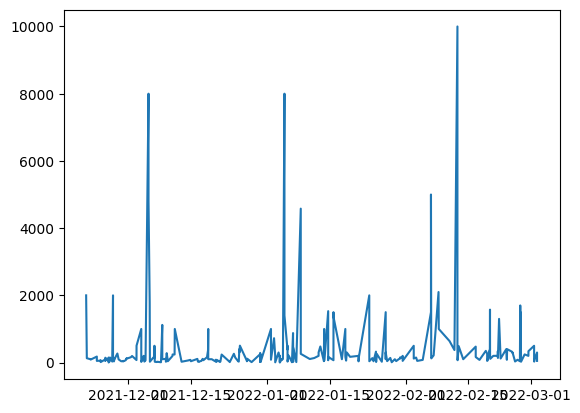

In [ ]:
import matplotlib.pyplot as plt
# Date wise expense using graph
plt.plot(expenses['Date'],expenses['INR'])

In [167]:
expenses

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March
...,...,...,...,...,...,...,...,...,...,...,...,...
272,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0,November
273,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0,November
274,2021-11-21 17:07:00,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0,November
275,2021-11-21 15:50:00,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0,November


<Axes: xlabel='month'>

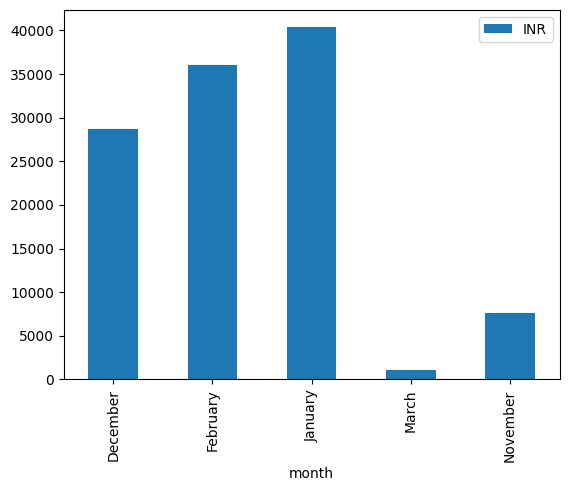

In [ ]:
# Bar chart showing expenses by month name
expenses.pivot_table(index='month',values='INR',aggfunc='sum').plot(kind='bar')

<Axes: xlabel='day_name'>

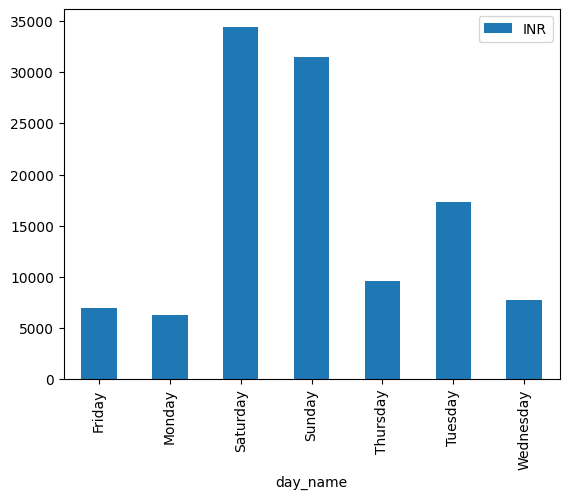

In [180]:
# Bar chart showing expenses by day name
expenses['day_name']=expenses['Date'].dt.day_name()
expenses.pivot_table(index=['day_name'],values='INR',aggfunc='sum').plot(kind='bar')

<Axes: xlabel='month,day_name'>

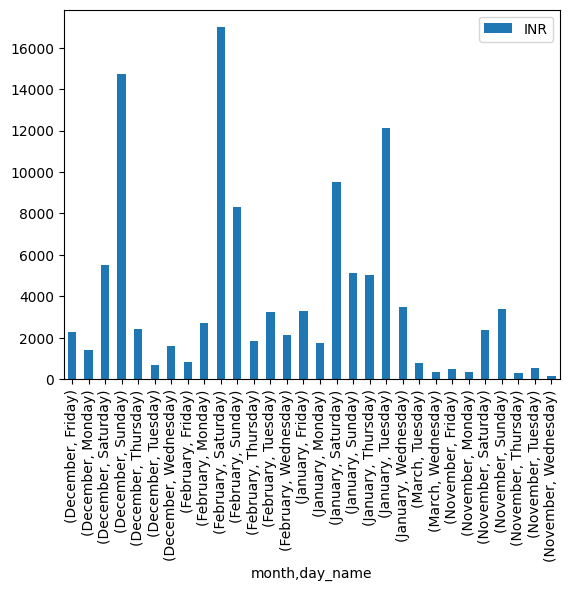

In [181]:
# Bar chart showing expense by month_name and it's day_names
expenses.pivot_table(index=['month','day_name'],values='INR',aggfunc='sum').plot(kind='bar')

<Axes: xlabel='day_name,month'>

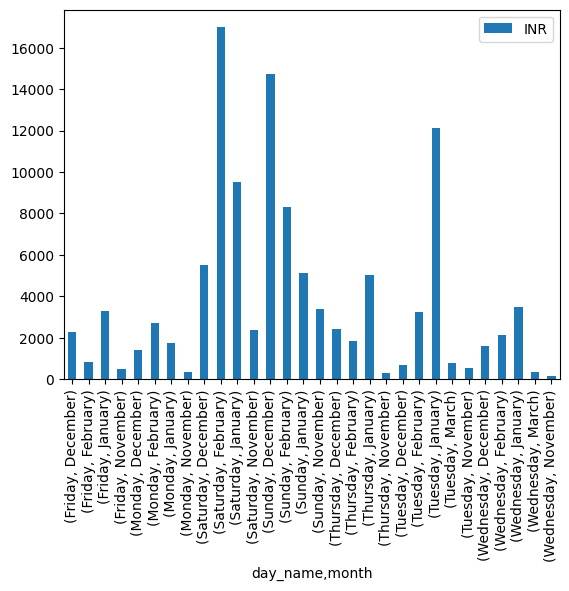

In [ ]:
# Bar chart showing expense by day_names and it's specific month
expenses.pivot_table(index=['day_name','month'],values='INR',aggfunc='sum').plot(kind='bar')